In [10]:
#IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Load the combined dataset
df = pd.read_csv("../data/processed/combined_spam_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (10162, 3)


,label,text,source
0,0,"Go until jurong point, crazy.. Available only ...",sms
1,0,Ok lar... Joking wif u oni...,sms
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,sms
3,0,U dun say so early hor... U c already then say...,sms
4,0,"Nah I don't think he goes to usf, he lives aro...",sms


In [12]:
# Basic info and missing values
print(df.info())
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10162 entries, 0 to 10161
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10162 non-null  int64 
 1   text    10162 non-null  object
 2   source  10162 non-null  object
dtypes: int64(1), object(2)
memory usage: 238.3+ KB
None

Columns: Index(['label', 'text', 'source'], dtype='object')

Missing values:
 label     0
text      0
source    0
dtype: int64


label
0    8047
1    2115
Name: count, dtype: int64


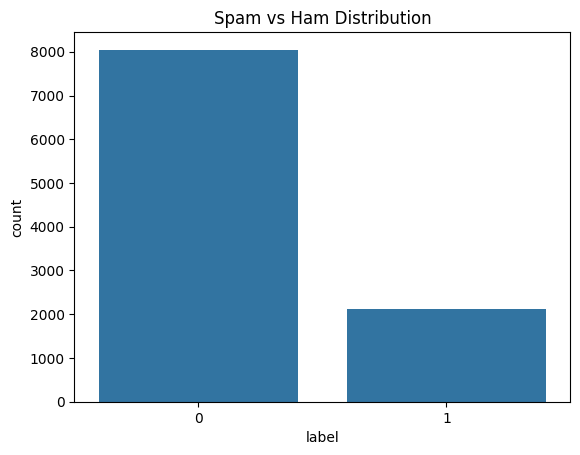

In [13]:
# Class distribution
print(df["label"].value_counts())

sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Distribution")
plt.show()

source
sms      5169
email    4993
Name: count, dtype: int64


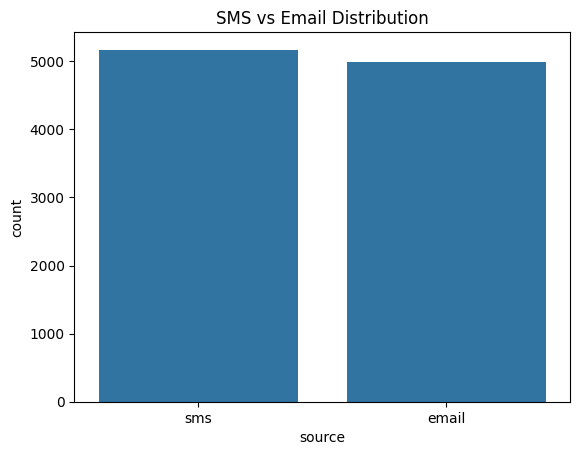

In [14]:
# Source distribution
print(df["source"].value_counts())

sns.countplot(x="source", data=df)
plt.title("SMS vs Email Distribution")
plt.show()

count    10162.000000
mean       565.545562
std       1193.103737
min          2.000000
25%         57.000000
50%        143.000000
75%        539.000000
max      32258.000000
Name: message_length, dtype: float64


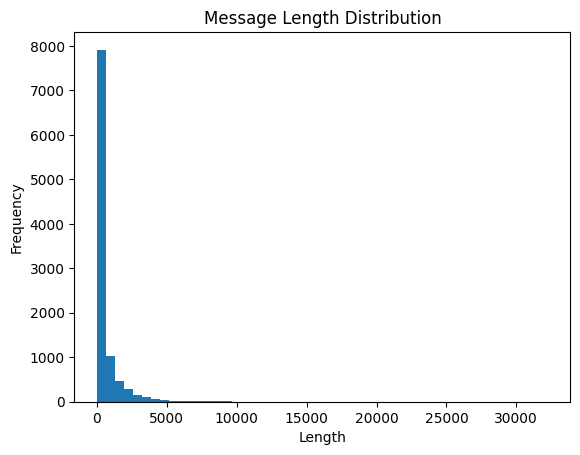

In [15]:
# Message length analysis
df["message_length"] = df["text"].apply(len)

print(df["message_length"].describe())

plt.hist(df["message_length"], bins=50)
plt.title("Message Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

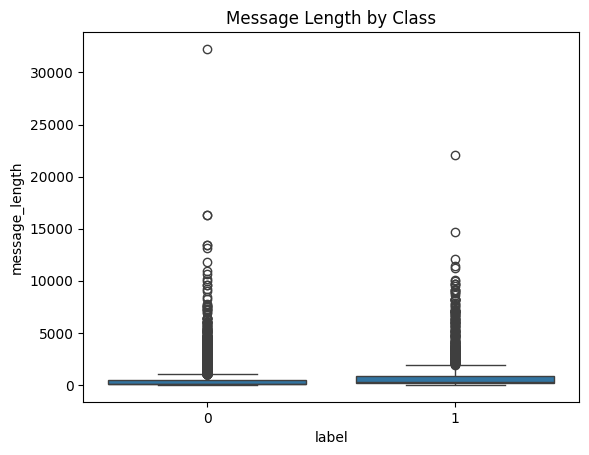

In [16]:
# Boxplot of message length by class
sns.boxplot(x="label", y="message_length", data=df)
plt.title("Message Length by Class")
plt.show()

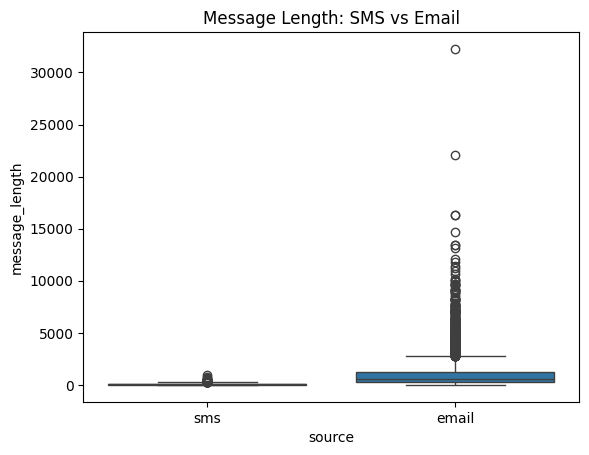

In [17]:
# Boxplot of message length by source(SMS vs Email)
sns.boxplot(x="source", y="message_length", data=df)
plt.title("Message Length: SMS vs Email")
plt.show()

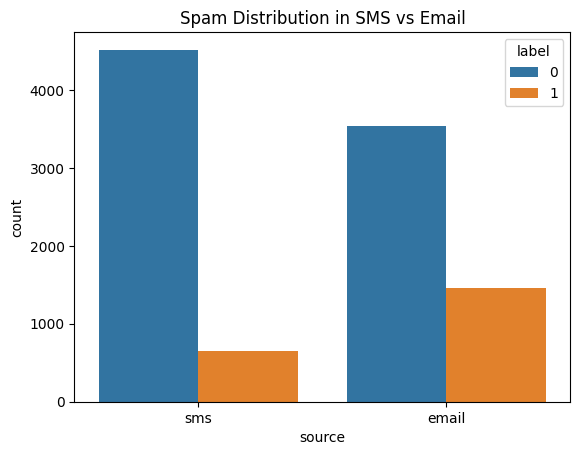

In [18]:
# Spam distribution in SMS vs Email
sns.countplot(x="source", hue="label", data=df)
plt.title("Spam Distribution in SMS vs Email")
plt.show()

In [19]:
# Common words analysis
from collections import Counter
import re

def get_words(text):
    words = re.findall(r'\w+', text.lower())
    return words

all_words = []

for text in df["text"]:
    all_words.extend(get_words(text))

common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 26377), ('to', 22063), ('ect', 13693), ('and', 13592), ('a', 10978), ('for', 10971), ('of', 10613), ('you', 10194), ('i', 9071), ('in', 8471), ('is', 7835), ('subject', 7829), ('on', 7669), ('this', 7401), ('hou', 7182), ('enron', 6442), ('be', 5338), ('that', 5257), ('we', 4628), ('your', 4619)]
